<a href="https://colab.research.google.com/github/MarMastro/pruebas_challenge/blob/master/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [ ]:

import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación

### Análisis por tienda.




In [ ]:
# Facturación por tienda
facturacion_tienda1 = tienda['Precio'].sum()
facturacion_tienda2 = tienda2['Precio'].sum()
facturacion_tienda3 = tienda3['Precio'].sum()
facturacion_tienda4 = tienda4['Precio'].sum()

# Mostrar resultados
print(f"Tienda 1 facturó: ${facturacion_tienda1:,.2f}")
print(f"Tienda 2 facturó: ${facturacion_tienda2:,.2f}")
print(f"Tienda 3 facturó: ${facturacion_tienda3:,.2f}")
print(f"Tienda 4 facturó: ${facturacion_tienda4:,.2f}")

# Crear un diccionario con los totales
facturaciones = {
                'Tienda 1': facturacion_tienda1,
                'Tienda 2': facturacion_tienda2,
                'Tienda 3': facturacion_tienda3,
                'Tienda 4': facturacion_tienda4
                }



Tienda 1 facturó: $1,150,880,400.00
Tienda 2 facturó: $1,116,343,500.00
Tienda 3 facturó: $1,098,019,600.00
Tienda 4 facturó: $1,038,375,700.00


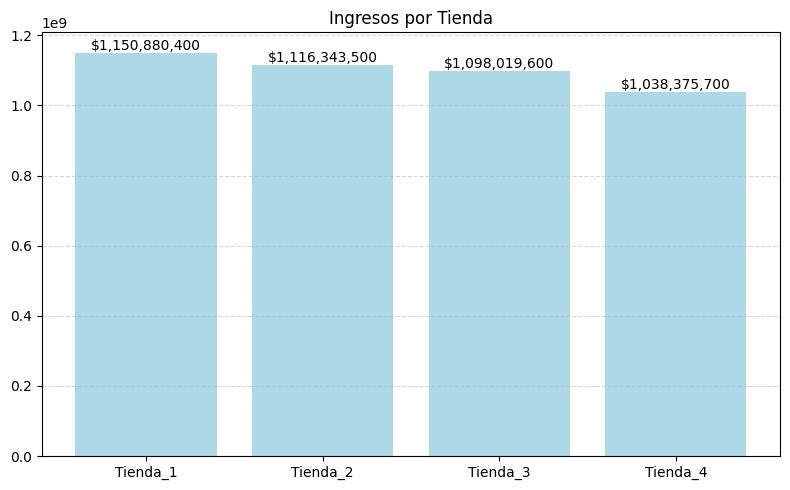

In [ ]:
import matplotlib.pyplot as plt
pd.options.display.float_format = '{.2f}'.format

# Valores de facturación (eje y)
valores_facturacion = list(facturaciones.values())

# Datos de las tiendas
tiendas = ['Tienda_1', 'Tienda_2', 'Tienda_3', 'Tienda_4']
facturacion_tiendas = [facturacion_tienda1, facturacion_tienda2, facturacion_tienda3, facturacion_tienda4]

# Creación gráfico
plt.figure (figsize=(8, 5))
barras = plt.bar(tiendas, facturacion_tiendas, color = 'lightblue')

# Etiquetas
plt.title('Ingresos por Tienda')

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Mostrar resultados encima de las barras
for i, valor in enumerate(valores_facturacion):
  plt.text(i, valor, f"${valor:,.0f}", ha='center', va='bottom')

# Mostrar gráfico
plt.tight_layout()
plt.show()




En el gráfico anterior se observa que la mayor facturación es la de la Tienda 1.


# 2. Ventas por categoría

In [ ]:
# Crear diccionario con las tiendas
tiendas = {'Tienda 1': tienda,
           'Tienda 2': tienda2,
           'Tienda 3': tienda3,
           'Tienda 4': tienda4}

# Imprimir facturación por categoría en cada tienda con formato
for nombre, df in tiendas.items():
    facturacion_categoria = df.groupby('Categoría del Producto')['Precio'].sum()
    print(f"\nFacturación por categoría en {nombre}:")

    for categoria, valor in facturacion_categoria.sort_values(ascending=False).items():
        print(f"  {categoria}: ${valor:,.2f}")


# Crear un DataFrame con la facturación por categoría para cada tienda
facturacion_por_categoria = pd.DataFrame()

for nombre, df in tiendas.items():
    # Agrupar por categoría y sumar la facturación
    facturacion_categoria = df.groupby('Categoría del Producto')['Precio'].sum()
    facturacion_por_categoria[nombre] = facturacion_categoria



Facturación por categoría en Tienda 1:
  Electrónicos: $429,493,500.00
  Electrodomésticos: $363,685,200.00
  Muebles: $187,633,700.00
  Instrumentos musicales: $91,299,000.00
  Deportes y diversión: $39,290,000.00
  Juguetes: $17,995,700.00
  Artículos para el hogar: $12,698,400.00
  Libros: $8,784,900.00

Facturación por categoría en Tienda 2:
  Electrónicos: $410,831,100.00
  Electrodomésticos: $348,567,800.00
  Muebles: $176,426,300.00
  Instrumentos musicales: $104,990,300.00
  Deportes y diversión: $34,744,500.00
  Juguetes: $15,945,400.00
  Artículos para el hogar: $14,746,900.00
  Libros: $10,091,200.00

Facturación por categoría en Tienda 3:
  Electrónicos: $410,775,800.00
  Electrodomésticos: $329,237,900.00
  Muebles: $201,072,100.00
  Instrumentos musicales: $77,380,900.00
  Deportes y diversión: $35,593,100.00
  Juguetes: $19,401,100.00
  Artículos para el hogar: $15,060,000.00
  Libros: $9,498,700.00

Facturación por categoría en Tienda 4:
  Electrónicos: $409,476,100.00

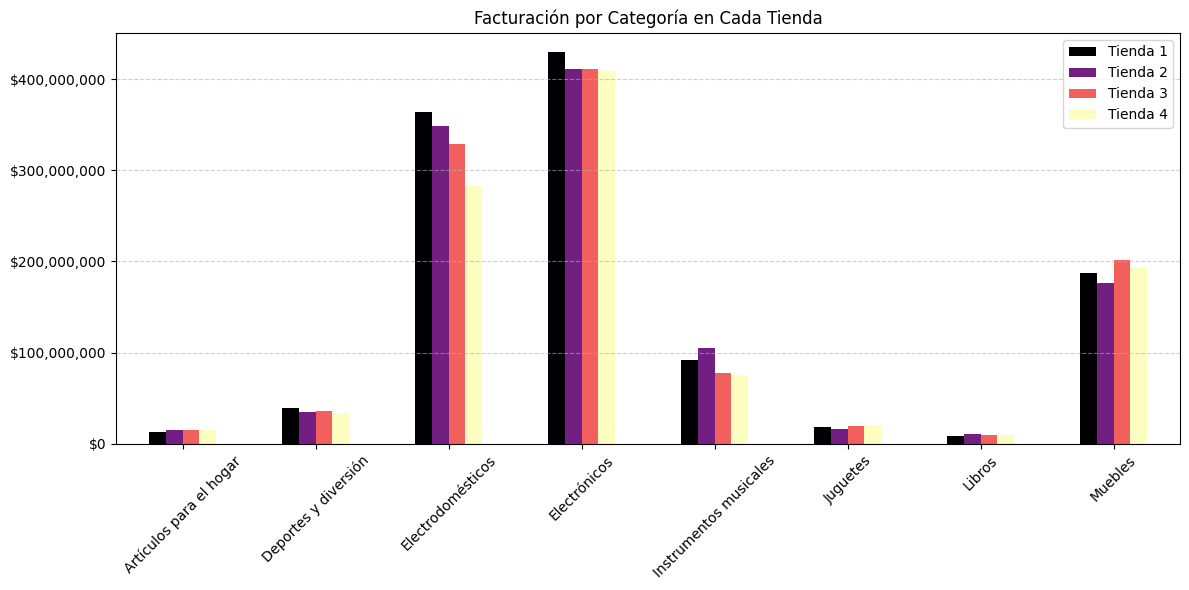

In [ ]:
#Crear gráfico de barras agrupadas
ax = facturacion_por_categoria.plot(kind='bar', figsize=(12, 6), colormap='magma')

# Añadir título y etiquetas
plt.title('Facturación por Categoría en Cada Tienda')
ax.set_xlabel('')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Formatear los valores en el eje Y con comas
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))

# Ajustar la disposición
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# 3. Calificación promedio de la tienda


In [ ]:
# Calificación promedio por tienda
Calificación_promedio=tienda['Calificación'].mean()
Calificación_promedio2=tienda2['Calificación'].mean()
Calificación_promedio3=tienda3['Calificación'].mean()
Calificación_promedio4=tienda4['Calificación'].mean()

#Imprimir los Resultados
print(f'Calificación promedio de la 1era tienda: {Calificación_promedio:.2f}')
print(f'Calificación promedio de la 2da tienda: {Calificación_promedio2:.2f}')
print(f'Calificación promedio de la 3ra tienda: {Calificación_promedio3:.2f}')
print(f'Calificación promedio de la 4ta tienda: {Calificación_promedio4:.2f}')

Calificación promedio de la 1era tienda: 3.98
Calificación promedio de la 2da tienda: 4.04
Calificación promedio de la 3ra tienda: 4.05
Calificación promedio de la 4ta tienda: 4.00


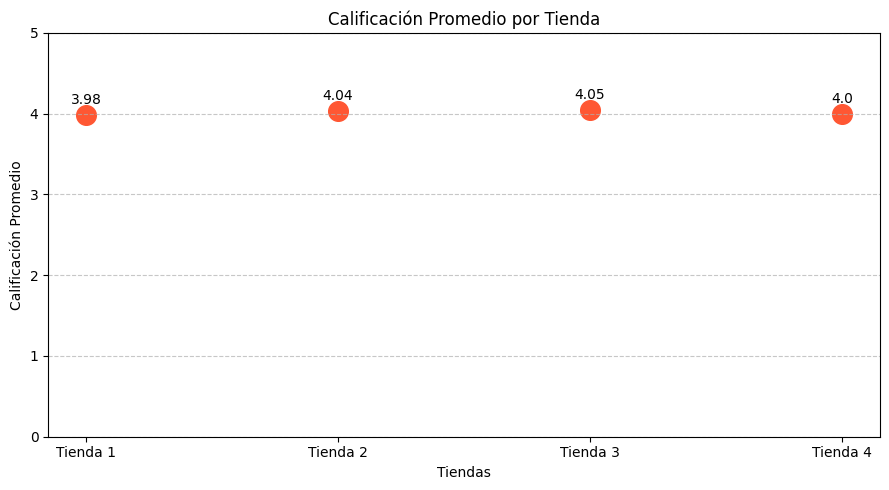

In [ ]:
# Crear lista
calificacion = [Calificación_promedio, Calificación_promedio2, Calificación_promedio3, Calificación_promedio4]
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
plt.figure(figsize=(9,5))
plt.scatter(nombres_tiendas, calificacion, color='#FF5733', s=200)

plt.title('Calificación Promedio por Tienda')
plt.xlabel('Tiendas')
plt.ylabel('Calificación Promedio')
plt.ylim(0,5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el valor al lado de cada punto
for i, calificacion_valor in enumerate(calificacion):
    plt.text(i, calificacion_valor + 0.1, round(calificacion_valor,2), ha='center', va='bottom')

plt.tight_layout()
plt.show()


# 4. Productos más y menos vendidos

In [ ]:
# Crear diccionario con las tiendas
tiendas = {
    'Tienda 1': tienda,
    'Tienda 2': tienda2,
    'Tienda 3': tienda3,
    'Tienda 4': tienda4
}

# Mostrar ventas por categoría, categoría más y menos vendida en cada tienda
for nombre, df in tiendas.items():
    ventas_categoria = df['Categoría del Producto'].value_counts()
    total_ventas = ventas_categoria.sum()  # Total de productos vendidos

    print(f"\nVentas por categoría en {nombre}:\n{ventas_categoria}")

    categoria_mas_vendida = ventas_categoria.idxmax()
    ventas_max = ventas_categoria.max()

    categoria_menos_vendida = ventas_categoria.idxmin()
    ventas_min = ventas_categoria.min()

    print(f"Categoría más vendida: {categoria_mas_vendida} ({ventas_max} ventas)")
    print(f"Categoría menos vendida: {categoria_menos_vendida} ({ventas_min} ventas)")
    print(f"Total de productos vendidos: {total_ventas} productos")

# Crear tabla resumen con ventas por categoría en cada tienda
ventas_por_categoria = pd.DataFrame({
    'Tienda 1': tienda['Categoría del Producto'].value_counts(),
    'Tienda 2': tienda2['Categoría del Producto'].value_counts(),
    'Tienda 3': tienda3['Categoría del Producto'].value_counts(),
    'Tienda 4': tienda4['Categoría del Producto'].value_counts()
}).fillna(0)


Ventas por categoría en Tienda 1:
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64
Categoría más vendida: Muebles (465 ventas)
Categoría menos vendida: Artículos para el hogar (171 ventas)
Total de productos vendidos: 2359 productos

Ventas por categoría en Tienda 2:
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64
Categoría más vendida: Muebles (442 ventas)
Categoría menos vendida: Artículos para el hogar (181 ventas)
Total de productos vendidos: 2359 productos

Ventas por categoría en Tienda 3:
C

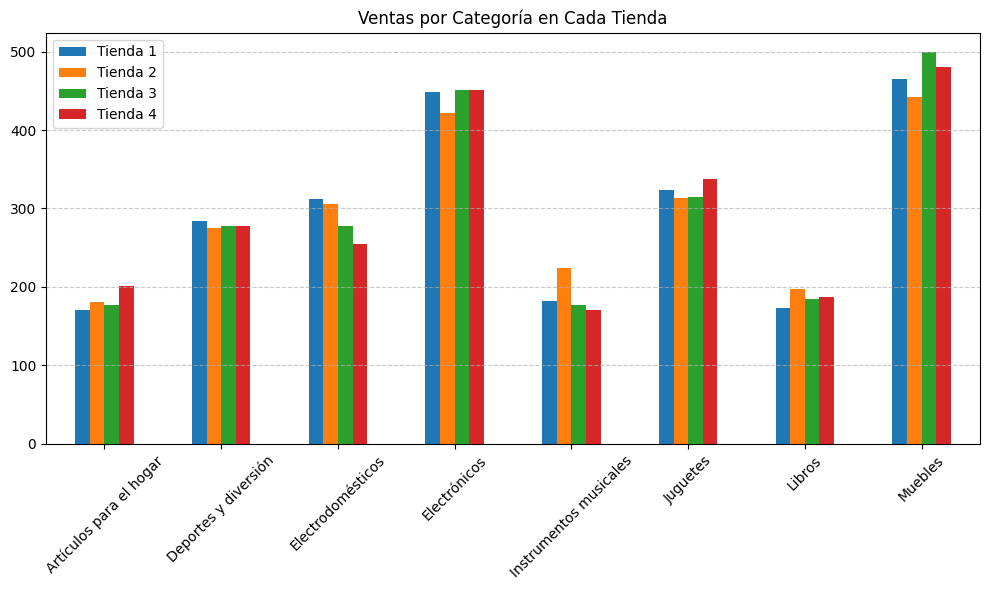

In [ ]:
# Crear gráfico de barras agrupadas
ax = ventas_por_categoria.plot(kind='bar', figsize=(10, 6))
plt.title('Ventas por Categoría en Cada Tienda')
ax.set_xlabel('')  # Esto ahora sí funciona porque 'ax' está definido correctamente
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

In [ ]:
tiendas = {
    'Tienda 1': tienda,
    'Tienda 2': tienda2,
    'Tienda 3': tienda3,
    'Tienda 4': tienda4
}

costo_envio_promedio = {}

for nombre, df in tiendas.items():
    promedio = df['Costo de envío'].mean()
    costo_envio_promedio[nombre] = promedio
    # Mostrar costo de envío promedio de la tienda
    print(f"Costo de envío promedio en {nombre}: ${promedio:,.2f}")

Costo de envío promedio en Tienda 1: $26,018.61
Costo de envío promedio en Tienda 2: $25,216.24
Costo de envío promedio en Tienda 3: $24,805.68
Costo de envío promedio en Tienda 4: $23,459.46


In [ ]:
costo_envio_total = {}

for nombre, df in tiendas.items():
    total = df['Costo de envío'].sum()
    costo_envio_total[nombre] = total
    print(f"Costo de envío total en {nombre}: ${total:,.2f}")

Costo de envío total en Tienda 1: $61,377,900.00
Costo de envío total en Tienda 2: $59,485,100.00
Costo de envío total en Tienda 3: $58,516,600.00
Costo de envío total en Tienda 4: $55,317,400.00


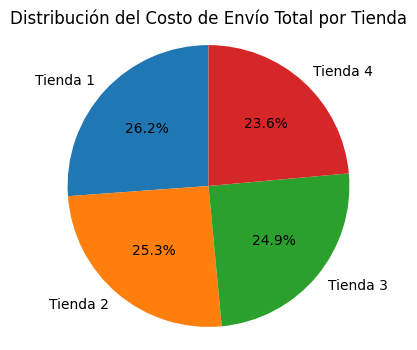

In [ ]:

# Crear el gráfico de torta
plt.figure(figsize=(4, 4))
plt.pie(costo_envio_total.values(), labels=costo_envio_total.keys(), autopct='%1.1f%%', startangle=90)
plt.title('Distribución del Costo de Envío Total por Tienda')
plt.axis('equal')  # Para que el gráfico de torta sea circular
plt.show()